Imports of packages

In [4]:
!nvidia-smi

Mon Jun 15 19:06:40 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 595.71.05              Driver Version: 595.71.05      CUDA Version: 13.2     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-PCIE-40GB          On  |   00000000:37:00.0 Off |                    0 |
| N/A   42C    P0             79W /  250W |   36912MiB /  40960MiB |     36%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [5]:
import numpy as np
import torch
import matplotlib.pyplot as plt
import monai
import zarr
import nibabel as nib
from monai.data import DataLoader, Dataset
from pathlib import Path
from monai.networks.nets import DynUNet
from time import perf_counter as time
import pandas as pd
from skimage import measure
from scipy.ndimage import distance_transform_edt

## 1. Data

## Late fusion vs. early fusion

**Early fusion** (the sibling notebook `2d_segmenting_multichannel.ipynb`) stacks the xray and neutron images as a 2-channel input tensor before the model sees them:

```
[xray_slice, neutron_slice]  →  DynUNet(in_channels=2)  →  probs  (3 classes)
```

A single network is trained end-to-end on both modalities simultaneously, so it can learn cross-modal correlations in its very first layer.

---

**Late fusion** (this notebook) trains two completely independent DynUnets — one per modality — and combines their predictions *after* the sigmoid activation:

```
xray_slice    →  DynUNet_xray(in_channels=1)    →  probs_xray   \
                                                                   →  mean  →  probs_fused  (3 classes)
neutron_slice →  DynUNet_neutron(in_channels=1) →  probs_neutron /
```

Each model specialises on its own modality. At inference the two probability maps are averaged with equal weight. Late fusion is easy to interpret (you can inspect each branch separately) and robust when one modality is unavailable, but requires training two models and has twice the parameters.

Both approaches use the same train / test split and the same DiceCE loss so their Dice scores are directly comparable.

In [6]:
from scipy.ndimage import binary_dilation, binary_fill_holes, zoom


IMAGE_NII       = Path("/work3/killeg/data/xray_1.nii")
NEUTRON_NII     = Path("/work3/killeg/data/neutron0.nii")
SEG_NII         = Path("/zhome/d8/d/230907/me/meteorite/masks/ROI_total.nii.gz")
NEUTRON_SEG_NII = Path("/zhome/d8/d/230907/me/meteorite/masks/neutron_ROI_final.nii.gz")

# Xray — full resolution (1888, 360, 1450)
img_vol = nib.load(IMAGE_NII).get_fdata(dtype=np.float32)
img_vol = (img_vol - img_vol.min()) / (img_vol.max() - img_vol.min())

# Neutron — already registered to xray_1 space (1888, 360, 1450); no zoom needed.
# Valid data is only in H-slices 700–1700; outside that range the volume is zero-padded.
NEUTRON_H_START = 700
NEUTRON_H_END   = 1700
neut_raw  = nib.load(NEUTRON_NII).get_fdata(dtype=np.float32)   # (1888, 360, 1450)
neut_vol  = np.zeros_like(neut_raw)
neut_valid = neut_raw[NEUTRON_H_START:NEUTRON_H_END]
neut_vol[NEUTRON_H_START:NEUTRON_H_END] = (
    (neut_valid - neut_valid.min()) / (neut_valid.max() - neut_valid.min() + 1e-8)
)

# Xray segmentation was annotated at half resolution (944, 180, 725).
# Upsample 2× with nearest-neighbour to match xray_1 space.
seg_raw = nib.load(SEG_NII).get_fdata(dtype=np.float32)   # (944, 180, 725)
seg_vol = zoom(seg_raw, 2, order=0)                         # (1888, 360, 1450)

unique, counts = np.unique(seg_vol, return_counts=True)
print('xray seg labels:', dict(zip(unique.astype(int), (counts / counts[0]).round(4))))

# Xray segmentation — one binary channel per clast type
seg_dark   = (seg_vol == 1).astype(np.float32)
seg_bright = (seg_vol == 2).astype(np.float32)
seg_white  = (seg_vol == 3).astype(np.float32)
binary_seg = np.stack([seg_dark, seg_bright, seg_white], axis=-1)  # (H, D, W, 3)

# Neutron segmentation — already at xray_1 resolution (1888, 360, 1450); use directly.
# Labels: 0=background, 1=dark clasts, 4=matrix. Bright/white not annotated.
neut_seg_raw  = nib.load(NEUTRON_SEG_NII).get_fdata(dtype=np.float32)  # (1888, 360, 1450)
neut_seg_dark = (neut_seg_raw == 1).astype(np.float32)
binary_seg_neutron = np.stack([
    neut_seg_dark,
    np.zeros_like(neut_seg_dark),   # bright: not annotated in neutron
    np.zeros_like(neut_seg_dark),   # white:  not annotated in neutron
], axis=-1)  # (H, D, W, 3)

# ROI mask — per-slice 2D dilation (20 iterations) + fill_holes.
# The annotation has 4–7 disconnected patches per slice; 20 iterations merges them
# into one region covering the full meteorite cross-section.
seg_nonzero = seg_vol != 0
roi_mask = np.zeros(seg_vol.shape, dtype=np.float32)
for i in range(seg_vol.shape[0]):
    dil = binary_dilation(seg_nonzero[i], iterations=20)
    roi_mask[i] = binary_fill_holes(dil)

print(f'xray_1 shape     : {img_vol.shape}')
print(f'neutron shape    : {neut_vol.shape}  (data in H-slices {NEUTRON_H_START}–{NEUTRON_H_END})')
print(f'ROI coverage     : {roi_mask.mean()*100:.1f}%')
print(f'Xray seg  — dark: {seg_dark.mean()*100:.2f}%  bright: {seg_bright.mean()*100:.2f}%  white: {seg_white.mean()*100:.2f}%')
print(f'Neutron seg — dark: {neut_seg_dark.mean()*100:.2f}%')

xray seg labels: {np.int64(0): np.float64(1.0), np.int64(1): np.float64(0.0226), np.int64(2): np.float64(0.0078), np.int64(3): np.float64(0.0015), np.int64(4): np.float64(0.3633)}
xray_1 shape     : (1888, 360, 1450)
neutron shape    : (1888, 360, 1450)  (data in H-slices 700–1700)
ROI coverage     : 38.6%
Xray seg  — dark: 1.62%  bright: 0.56%  white: 0.11%
Neutron seg — dark: 0.86%


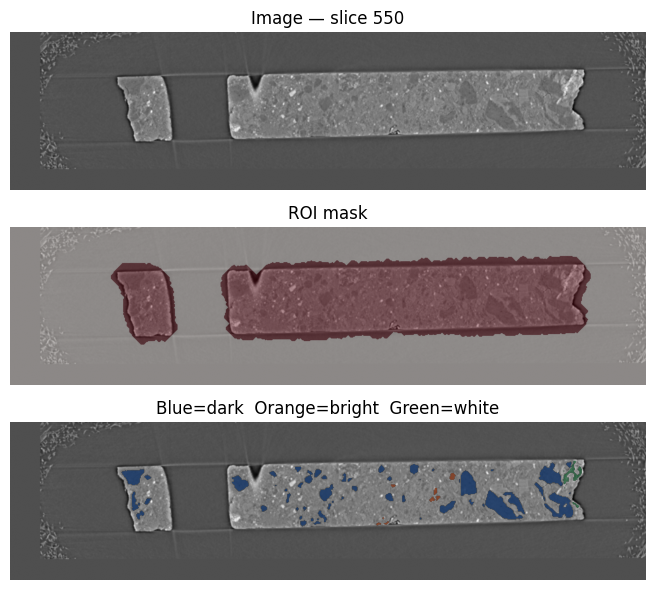

ROI coverage: 31.0%  |  dark: 3.09%  bright: 0.12%  white: 0.18%


In [7]:
SLICE_D = 550  # <-- change this

s   = img_vol[SLICE_D, :, :]
roi = roi_mask[SLICE_D, :, :]
seg = binary_seg[SLICE_D, :, :]   # (H, W, 3)

CLAST_NAMES = ['dark', 'bright', 'white']
CLAST_CMAPS = ['Blues', 'Oranges', 'Greens']

fig, axes = plt.subplots(3, 1, figsize=(18, 6))
axes[0].imshow(s, cmap='gray'); axes[0].set_title(f'Image — slice {SLICE_D}'); axes[0].axis('off')
axes[1].imshow(s, cmap='gray')
axes[1].imshow(roi, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
axes[1].set_title('ROI mask'); axes[1].axis('off')
axes[2].imshow(s, cmap='gray')
for c, (name, cmap) in enumerate(zip(CLAST_NAMES, CLAST_CMAPS)):
    axes[2].imshow(np.where(seg[:,:,c], 1, np.nan), cmap=cmap, alpha=0.7, vmin=0, vmax=1)
axes[2].set_title('Blue=dark  Orange=bright  Green=white'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f'ROI coverage: {roi.mean()*100:.1f}%  |  '
      f'dark: {seg[:,:,0].mean()*100:.2f}%  '
      f'bright: {seg[:,:,1].mean()*100:.2f}%  '
      f'white: {seg[:,:,2].mean()*100:.2f}%')

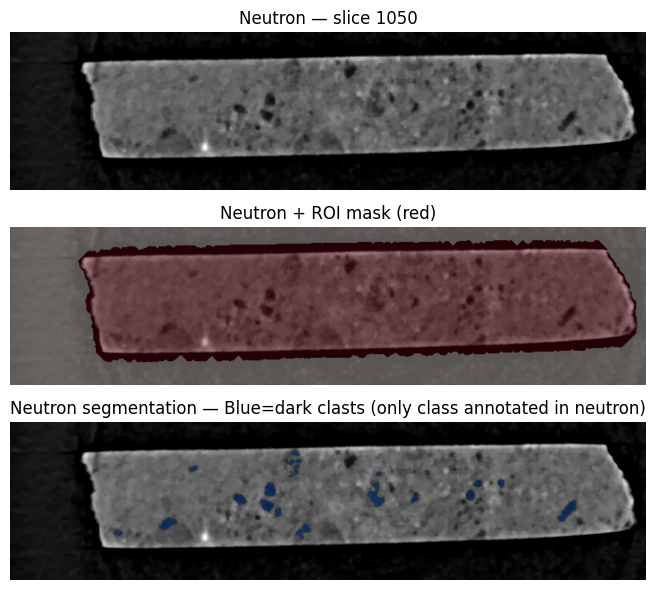

Xray   range : [0.131, 0.593]
Neutron range: [0.000, 0.322]
ROI coverage : 60.1%  |  neutron dark: 1.327%


In [8]:
SLICE_D = 1050  # <-- change this (must be in 700–1700 where neutron data exists)

s_x   = img_vol[SLICE_D, :, :]
s_n   = neut_vol[SLICE_D, :, :]
roi   = roi_mask[SLICE_D, :, :]
seg_n = binary_seg_neutron[SLICE_D, :, :, 0]   # dark channel only

fig, axes = plt.subplots(3, 1, figsize=(18, 6))
axes[0].imshow(s_n, cmap='gray'); axes[0].set_title(f'Neutron — slice {SLICE_D}'); axes[0].axis('off')
axes[1].imshow(s_n, cmap='gray')
axes[1].imshow(roi, cmap='Reds', alpha=0.35, vmin=0, vmax=1)
axes[1].set_title('Neutron + ROI mask (red)'); axes[1].axis('off')
axes[2].imshow(s_n, cmap='gray')
axes[2].imshow(np.where(seg_n, 1, np.nan), cmap='Blues', alpha=0.7, vmin=0, vmax=1)
axes[2].set_title('Neutron segmentation — Blue=dark clasts (only class annotated in neutron)'); axes[2].axis('off')
plt.tight_layout(); plt.show()
print(f'Xray   range : [{s_x.min():.3f}, {s_x.max():.3f}]')
print(f'Neutron range: [{s_n.min():.3f}, {s_n.max():.3f}]')
print(f'ROI coverage : {roi.mean()*100:.1f}%  |  neutron dark: {seg_n.mean()*100:.3f}%')

In [9]:
GOOD_START  = 180   # xray starts here; neutron only valid from NEUTRON_H_START (700)
GOOD_END    = 1700  # both modalities end here
BLOCK_SIZE  = 16
TEST_BLOCKS = 10
RANDOM_SEED = 40
CROP_SIZE   = (304, 1408)  # (D, W) — divisible by 8; fits within (360, 1450)

def center_crop(arr, h, w):
    """Center-crop array to (h, w) in its last two dims."""
    H, W = arr.shape[-2], arr.shape[-1]
    y0 = (H - h) // 2
    x0 = (W - w) // 2
    return np.ascontiguousarray(arr[..., y0:y0+h, x0:x0+w])

rng = np.random.default_rng(RANDOM_SEED)
block_starts = np.arange(GOOD_START, GOOD_END, BLOCK_SIZE)
block_starts = block_starts[block_starts + BLOCK_SIZE <= GOOD_END]
rng.shuffle(block_starts)
test_block_starts = sorted(block_starts[:TEST_BLOCKS])

test_idx  = sorted([i for b in test_block_starts for i in range(b, b + BLOCK_SIZE)])
train_idx = sorted(set(range(GOOD_START, GOOD_END)) - set(test_idx))

# has_neutron = 1.0 for slices where neutron data is valid (>= NEUTRON_H_START).
# Slices 180–699 are xray-only; the neutron loss is skipped for those.
train_files = [{
    'image_xray':    center_crop(img_vol[i][None],  *CROP_SIZE),
    'image_neutron': center_crop(neut_vol[i][None], *CROP_SIZE),
    'label_xray':    center_crop(binary_seg[i, :, :, :].transpose(2, 0, 1),         *CROP_SIZE),
    'label_neutron': center_crop(binary_seg_neutron[i, :, :, :].transpose(2, 0, 1), *CROP_SIZE),
    'roi':           center_crop(roi_mask[i, :, :], *CROP_SIZE)[None],
    'has_neutron':   np.array([float(i >= NEUTRON_H_START)]),
} for i in train_idx]
test_files = [{
    'image_xray':    center_crop(img_vol[i][None],  *CROP_SIZE),
    'image_neutron': center_crop(neut_vol[i][None], *CROP_SIZE),
    'label_xray':    center_crop(binary_seg[i, :, :, :].transpose(2, 0, 1),         *CROP_SIZE),
    'label_neutron': center_crop(binary_seg_neutron[i, :, :, :].transpose(2, 0, 1), *CROP_SIZE),
    'roi':           center_crop(roi_mask[i, :, :], *CROP_SIZE)[None],
    'has_neutron':   np.array([float(i >= NEUTRON_H_START)]),
} for i in test_idx]

print(f'Test  slices : {len(test_idx)}')
print(f'Train slices : {len(train_idx)}')
xray_only = sum(1 for i in train_idx if i < NEUTRON_H_START)
both      = sum(1 for i in train_idx if i >= NEUTRON_H_START)
print(f'  xray-only (180–699): {xray_only}  |  overlap (700–1700): {both}')
print(f'Item shapes  — image_xray: {train_files[0]["image_xray"].shape}'
      f'  label_xray: {train_files[0]["label_xray"].shape}')


Test  slices : 160
Train slices : 1360
  xray-only (180–699): 488  |  overlap (700–1700): 872
Item shapes  — image_xray: (1, 304, 1408)  label_xray: (3, 304, 1408)


In [10]:
# Per-slice sampling weights — higher weight → sampled more often during training.
# Default is 1.0 for every slice (uniform). After running gt-vs-pred, bump up
# slices where the model misses many clasts:
#   sample_weights[train_idx.index(80)] = 5.0   # emphasise anchor 80
#
# To weight automatically by FN count after prediction:
#   fns = [((binary_seg[:, _slab(i), :, :] == 1) & (pred_vol[:, :, _slab(i), :].transpose(1,0,2) == 0)).sum()
#          for i in train_idx]
#   sample_weights = np.array(fns, dtype=np.float32) + 1.0   # +1 so zero-FN slices still get sampled

sample_weights = np.ones(len(train_files), dtype=np.float32)
print(f'{len(sample_weights)} train slices, weights: min={sample_weights.min():.2f}  max={sample_weights.max():.2f}')


1360 train slices, weights: min=1.00  max=1.00


In [11]:
limage = train_files[20]
print(f"xray   min: {limage['image_xray'].min():.3f}   max: {limage['image_xray'].max():.3f}")
print(f"neutron min: {limage['image_neutron'].min():.3f}  max: {limage['image_neutron'].max():.3f}")

xray   min: 0.121   max: 0.588
neutron min: 0.000  max: 0.000


In [12]:
# Spatial augmentations applied to BOTH modalities and BOTH label maps together
# so the same random flip / rotation hits everything consistently.
train_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image_xray', 'image_neutron']),
    monai.transforms.RandGaussianNoised(keys=['image_xray', 'image_neutron'], prob=0.5, mean=0.1, std=0.1),
    monai.transforms.RandFlipd(
        keys=['image_xray', 'image_neutron', 'label_xray', 'label_neutron', 'roi'],
        prob=0.5, spatial_axis=0,
    ),
    monai.transforms.RandFlipd(
        keys=['image_xray', 'image_neutron', 'label_xray', 'label_neutron', 'roi'],
        prob=0.5, spatial_axis=1,
    ),
    monai.transforms.RandRotated(
        keys=['image_xray', 'image_neutron', 'label_xray', 'label_neutron', 'roi'],
        prob=0.2, range_x=0.3, range_y=0.0, range_z=0.0,
        mode=['bilinear', 'bilinear', 'nearest', 'nearest', 'nearest'],
    ),
])

test_transforms = monai.transforms.Compose([
    monai.transforms.ScaleIntensityd(keys=['image_xray', 'image_neutron']),
])

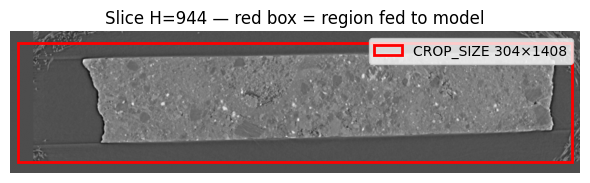

In [13]:
import matplotlib.patches as patches

SLICE_H = img_vol.shape[0] // 2   # <-- change this

img = img_vol[SLICE_H, :, :]   # (D, W)
H, W = img.shape
ch, cw = CROP_SIZE[0], CROP_SIZE[1]
y0 = (H - ch) // 2
x0 = (W - cw) // 2

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(img, cmap='gray')
ax.add_patch(patches.Rectangle(
    (x0, y0), cw, ch,
    linewidth=2, edgecolor='red', facecolor='none',
    label=f'CROP_SIZE {ch}×{cw}'
))
ax.legend(loc='upper right')
ax.set_title(f'Slice H={SLICE_H} — red box = region fed to model')
ax.axis('off')
plt.tight_layout(); plt.show()


## 2. Models

**This is where the neutron segmentation model lives.**

`model_neutron` is a `DynUNet(in_channels=1, out_channels=3)` that takes neutron slices as input and is trained to detect **dark clasts only** (the only class annotated in the neutron segmentation). Its loss is computed exclusively on channel 0 (dark):
```
loss_n = DiceCE(out_n[:, 0:1], targets_n[:, 0:1])
```

`model_xray` is an identical `DynUNet(in_channels=1, out_channels=3)` trained on xray slices with labels for all three classes (dark, bright, white).

Both models are completely independent — they share no weights. Their probability maps are fused **after inference** (see `slider-pred`).

In [14]:
# Two independent 1-channel DynUnets — identical architecture, separate weights.
model_xray = DynUNet(
    spatial_dims=2,
    in_channels=1,    # xray only
    out_channels=3,   # dark, bright, white
    kernel_size=[3, 3, 3, 3],
    strides=[1, 2, 2, 2],
    upsample_kernel_size=[2, 2, 2],
    dropout=0.2,
)
model_neutron = DynUNet(
    spatial_dims=2,
    in_channels=1,    # neutron only
    out_channels=3,
    kernel_size=[3, 3, 3, 3],
    strides=[1, 2, 2, 2],
    upsample_kernel_size=[2, 2, 2],
    dropout=0.2,
)

base_loss   = monai.losses.DiceCELoss(sigmoid=False, lambda_dice=1.0, lambda_ce=0.0)
optimizer_x = torch.optim.Adam(model_xray.parameters(),    lr=1e-2, weight_decay=1e-5)
optimizer_n = torch.optim.Adam(model_neutron.parameters(), lr=1e-2, weight_decay=1e-5)

In [15]:
USE_MODEL_CHECKPOINT = False
checkpoint_file = "/zhome/d8/d/230907/me/meteorite/weights/model_2d_multichannel_latefusion.pth"

if USE_MODEL_CHECKPOINT:
    checkpoint = torch.load(checkpoint_file)
    model_xray.load_state_dict(checkpoint['model_xray'])
    model_neutron.load_state_dict(checkpoint['model_neutron'])
    optimizer_x.load_state_dict(checkpoint['optimizer_xray'])
    optimizer_n.load_state_dict(checkpoint['optimizer_neutron'])

In [ ]:
NUM_EPOCHS = 50

from torch.utils.data import WeightedRandomSampler
sampler = WeightedRandomSampler(
    weights=sample_weights, num_samples=len(sample_weights), replacement=True
)
train_loader = DataLoader(
    Dataset(data=train_files, transform=train_transforms),
    batch_size=4, sampler=sampler, num_workers=2, persistent_workers=True, pin_memory=True,
)
test_loader = DataLoader(
    Dataset(data=test_files, transform=test_transforms),
    batch_size=4, shuffle=False,
)

# Sanity check
_batch = next(iter(DataLoader(Dataset(data=train_files, transform=train_transforms), batch_size=1, num_workers=0)))
_y = _batch['label_xray']
print('label_xray shape:', _y.shape)
for _c, _name in enumerate(['dark', 'bright', 'white']):
    print(f'  xray  {_name}: {(_y[:, _c] > 0).float().mean().item()*100:.4f}% positive')
_yn = _batch['label_neutron']
print(f'  neutron dark: {(_yn[:, 0] > 0).float().mean().item()*100:.4f}% positive')
del _batch, _y, _yn

model_xray    = model_xray.cuda()
model_neutron = model_neutron.cuda()
scheduler_x   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_x, T_max=NUM_EPOCHS, eta_min=1e-6)
scheduler_n   = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_n, T_max=NUM_EPOCHS, eta_min=1e-6)

if USE_MODEL_CHECKPOINT:
    all_train_losses = checkpoint['train_losses']
    all_test_losses  = checkpoint['test_losses']
    best_test_loss   = np.min(checkpoint['test_losses'])
else:
    all_train_losses = []
    all_test_losses  = []
    best_test_loss   = float('inf')

for epoch in range(NUM_EPOCHS):
    model_xray.train(); model_neutron.train()
    epoch_loss, steps = 0.0, 0
    for batch in train_loader:
        inp_x     = batch['image_xray'].cuda(non_blocking=True)
        inp_n     = batch['image_neutron'].cuda(non_blocking=True)
        targets_x = batch['label_xray'].cuda(non_blocking=True).float()
        targets_n = batch['label_neutron'].cuda(non_blocking=True).float()
        roi       = batch['roi'].cuda(non_blocking=True)
        valid_n   = batch['has_neutron'].squeeze(1).bool().cuda()  # (B,)

        # Xray branch: train on every slice (180–1700)
        optimizer_x.zero_grad()
        out_x = model_xray(inp_x)
        out_x = torch.where(roi.expand_as(out_x) > 0, out_x, torch.full_like(out_x, -20.0))
        loss_x = base_loss(out_x, targets_x)
        loss_x.backward()
        optimizer_x.step()

        # Neutron branch: only on slices where neutron data is valid (700–1700)
        if valid_n.any():
            optimizer_n.zero_grad()
            out_n  = model_neutron(inp_n[valid_n])
            roi_n  = roi[valid_n]
            out_n  = torch.where(roi_n.expand_as(out_n) > 0, out_n, torch.full_like(out_n, -20.0))
            loss_n = base_loss(out_n[:, 0:1], targets_n[valid_n, 0:1])
            loss_n.backward()
            optimizer_n.step()
            epoch_loss += (loss_x.detach() + loss_n.detach()) / 2
        else:
            epoch_loss += loss_x.detach()
        steps += 1

    train_loss = epoch_loss.item() / steps
    all_train_losses.append(train_loss)
    scheduler_x.step(); scheduler_n.step()

    model_xray.eval(); model_neutron.eval()
    epoch_loss, steps = 0.0, 0
    with torch.no_grad():
        for batch in test_loader:
            inp_x     = batch['image_xray'].cuda(non_blocking=True)
            inp_n     = batch['image_neutron'].cuda(non_blocking=True)
            targets_x = batch['label_xray'].cuda(non_blocking=True).float()
            targets_n = batch['label_neutron'].cuda(non_blocking=True).float()
            roi       = batch['roi'].cuda(non_blocking=True)
            valid_n   = batch['has_neutron'].squeeze(1).bool().cuda()

            out_x = model_xray(inp_x)
            out_x = torch.where(roi.expand_as(out_x) > 0, out_x, torch.full_like(out_x, -20.0))
            loss_x = base_loss(out_x, targets_x)

            if valid_n.any():
                out_n  = model_neutron(inp_n[valid_n])
                roi_n  = roi[valid_n]
                out_n  = torch.where(roi_n.expand_as(out_n) > 0, out_n, torch.full_like(out_n, -20.0))
                loss_n = base_loss(out_n[:, 0:1], targets_n[valid_n, 0:1])
                epoch_loss += (loss_x + loss_n) / 2
            else:
                epoch_loss += loss_x
            steps += 1

    test_loss = epoch_loss.item() / steps
    all_test_losses.append(test_loss)

    if test_loss < best_test_loss:
        best_test_loss = test_loss
        torch.save({
            'model_xray':        model_xray.state_dict(),
            'model_neutron':     model_neutron.state_dict(),
            'optimizer_xray':    optimizer_x.state_dict(),
            'optimizer_neutron': optimizer_n.state_dict(),
            'epoch':             epoch,
            'train_losses':      all_train_losses,
            'test_losses':       all_test_losses,
        }, checkpoint_file)
        print(f'  -> Saved (test loss: {test_loss:.4f})')

    print(f'Epoch {epoch+1:3d}  train={train_loss:.4f}  test={test_loss:.4f}'
          f'  lr={scheduler_x.get_last_lr()[0]:.2e}')


label_xray shape: torch.Size([1, 3, 304, 1408])
  xray  dark: 1.3438% positive
  xray  bright: 0.0056% positive
  xray  white: 0.0682% positive
  neutron dark: 0.0000% positive
  -> Saved (test loss: 1.0047)
Epoch   1  train=0.9461  test=1.0047  lr=9.99e-03
  -> Saved (test loss: 0.9247)
Epoch   2  train=0.9553  test=0.9247  lr=9.96e-03
Epoch   3  train=0.8958  test=1.0097  lr=9.91e-03
Epoch   4  train=0.9835  test=0.9436  lr=9.84e-03
  -> Saved (test loss: 0.8979)
Epoch   5  train=0.9074  test=0.8979  lr=9.76e-03
Epoch   6  train=0.9437  test=0.9835  lr=9.65e-03
Epoch   7  train=0.9598  test=0.9671  lr=9.52e-03
Epoch   8  train=0.9751  test=1.0059  lr=9.38e-03
Epoch   9  train=0.9934  test=1.1536  lr=9.22e-03
Epoch  10  train=0.9983  test=1.0036  lr=9.05e-03
Epoch  11  train=0.9992  test=1.0025  lr=8.85e-03
Epoch  12  train=0.9983  test=1.0026  lr=8.64e-03
Epoch  13  train=0.9972  test=0.9973  lr=8.42e-03
Epoch  14  train=1.0017  test=0.9959  lr=8.19e-03
Epoch  15  train=1.0030  test=

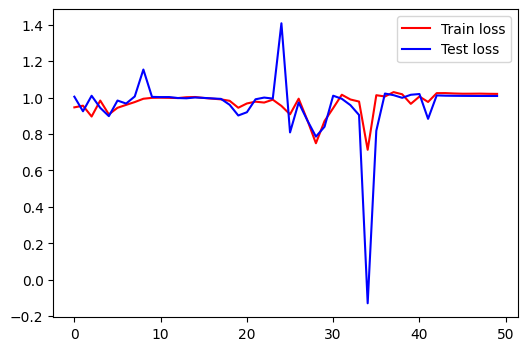

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(all_train_losses, 'r', label='Train loss')
ax.plot(all_test_losses,  'b', label='Test loss')
ax.legend()
plt.show()

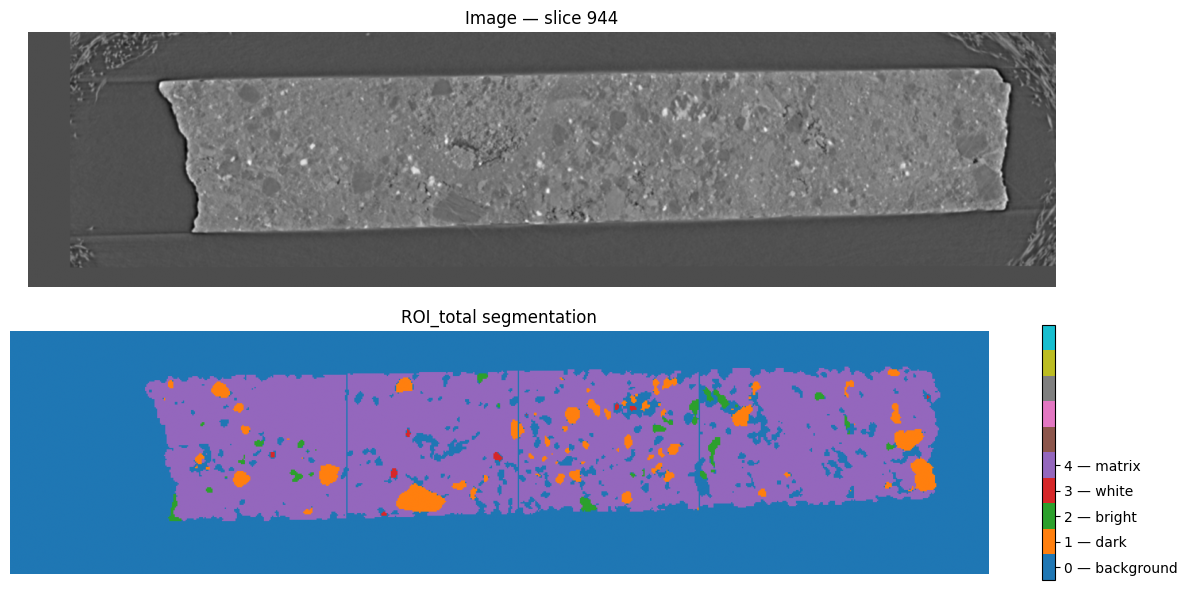

In [ ]:
SLICE_D = img_vol.shape[0] // 2   # <-- change this

s = img_vol[SLICE_D, :, :]
m = seg_vol[SLICE_D, :, :]

LABEL_NAMES = {0: 'background', 1: 'dark', 2: 'bright', 3: 'white', 4: 'matrix'}

fig, axes = plt.subplots(2, 1, figsize=(12, 6))
axes[0].imshow(s, cmap='gray'); axes[0].set_title(f'Image — slice {SLICE_D}'); axes[0].axis('off')
im = axes[1].imshow(m, cmap='tab10', vmin=-0.5, vmax=9.5)
axes[1].set_title('ROI_total segmentation'); axes[1].axis('off')
cb = plt.colorbar(im, ax=axes[1], fraction=0.03)
present = sorted(np.unique(m).astype(int))
cb.set_ticks(present)
cb.set_ticklabels([f'{l} — {LABEL_NAMES.get(l, "?")}' for l in present])
plt.tight_layout()
plt.show()


In [ ]:
import ipywidgets as widgets

CLAST_NAMES = ['dark', 'bright', 'white']
CLAST_CMAPS = ['Blues', 'Oranges', 'Greens']

model_xray.eval(); model_neutron.eval()
pred_vol = np.zeros((3, img_vol.shape[0], img_vol.shape[1], img_vol.shape[2]))  # (3, H, D, W)

with torch.no_grad():
    for i in range(img_vol.shape[0]):
        sl_x = img_vol[i, :, :]
        sl_x = (sl_x - sl_x.min()) / (sl_x.max() - sl_x.min() + 1e-8)
        sl_n = neut_vol[i, :, :]
        sl_n = (sl_n - sl_n.min()) / (sl_n.max() - sl_n.min() + 1e-8)

        inp_x = torch.from_numpy(sl_x[None, None]).float().cuda()  # (1, 1, D, W)
        inp_n = torch.from_numpy(sl_n[None, None]).float().cuda()  # (1, 1, D, W)

        logits_x = monai.inferers.sliding_window_inference(
            inp_x, CROP_SIZE, sw_batch_size=1, predictor=model_xray, overlap=0.25,
        )
        logits_n = monai.inferers.sliding_window_inference(
            inp_n, CROP_SIZE, sw_batch_size=1, predictor=model_neutron, overlap=0.25,
        )

        probs_x = torch.sigmoid(logits_x).squeeze(0).cpu().numpy()   # (3, D, W)
        probs_n = torch.sigmoid(logits_n).squeeze(0).cpu().numpy()   # (3, D, W)

        # Channel-specific late fusion:
        # - dark (ch 0): average both branches — neutron model was trained on dark clasts
        # - bright (ch 1) / white (ch 2): xray branch only — not annotated in neutron
        probs_fused = probs_x.copy()
        probs_fused[0] = (probs_x[0] + probs_n[0]) / 2

        pred_vol[:, i, :, :] = probs_fused * roi_mask[i, :, :][None]

def show(i):
    fig, axes = plt.subplots(3, 1, figsize=(16, 9))

    axes[0].imshow(img_vol[i, :, :], cmap='gray')
    axes[0].set_title(f'Xray — slice H={i}'); axes[0].axis('off')

    axes[1].imshow(neut_vol[i, :, :], cmap='gray')
    axes[1].set_title(f'Neutron — slice H={i}'); axes[1].axis('off')

    axes[2].imshow(img_vol[i, :, :], cmap='gray')
    for c, (name, cmap) in enumerate(zip(CLAST_NAMES, CLAST_CMAPS)):
        p = pred_vol[c, i, :, :]
        axes[2].imshow(np.where(p > 0.05, p, np.nan), cmap=cmap, alpha=0.6, vmin=0, vmax=1)
    axes[2].set_title('Fused prediction — Blue=dark (xray+neutron)  Orange=bright (xray)  Green=white (xray)')
    axes[2].axis('off')

    plt.tight_layout(); plt.show()

widgets.interact(show, i=widgets.IntSlider(min=0, max=img_vol.shape[0]-1, step=1, value=1050))

/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:231: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch/torch/csrc/autograd/python_variable_indexing.cpp:345.)
  win_data = inputs[unravel_slice[0]].to(sw_device)
/dtu/3d-imaging-center/courses/02510/groups/killian/gpu_env/lib/python3.11/site-packages/monai/inferers/utils.py:370: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at /pytorch

interactive(children=(IntSlider(value=1050, description='i', max=1887), Output()), _dom_classes=('widget-inter…

<function __main__.show(i)>

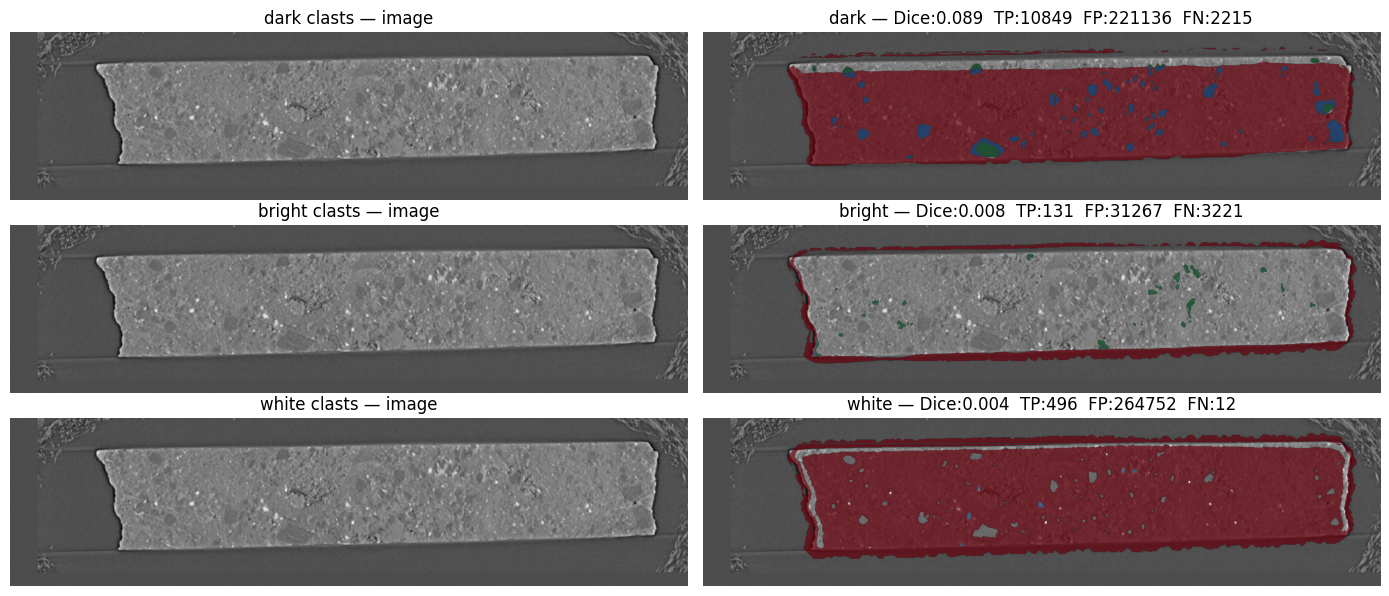

In [ ]:
SLICE_H = img_vol.shape[0] // 2   # <-- change this

img  = img_vol[SLICE_H, :, :]
CLAST_NAMES = ['dark', 'bright', 'white']

fig, axes = plt.subplots(len(CLAST_NAMES), 2, figsize=(14, 2*len(CLAST_NAMES)))

for c, name in enumerate(CLAST_NAMES):
    gt   = binary_seg[SLICE_H, :, :, c]
    pred = pred_vol[c, SLICE_H, :, :] > 0.5

    fn_mask = (gt == 1) & (pred == 0)
    tp_mask = (gt == 1) & (pred == 1)
    fp_mask = (gt == 0) & (pred == 1)

    axes[c, 0].imshow(img, cmap='gray')
    axes[c, 0].set_title(f'{name} clasts — image'); axes[c, 0].axis('off')

    axes[c, 1].imshow(img, cmap='gray')
    axes[c, 1].imshow(np.where(fn_mask, 1, np.nan), cmap='Greens', alpha=0.7, vmin=0, vmax=1)
    axes[c, 1].imshow(np.where(tp_mask, 1, np.nan), cmap='Blues',  alpha=0.7, vmin=0, vmax=1)
    axes[c, 1].imshow(np.where(fp_mask, 1, np.nan), cmap='Reds',   alpha=0.7, vmin=0, vmax=1)

    n_tp = int(tp_mask.sum()); n_fp = int(fp_mask.sum()); n_fn = int(fn_mask.sum())
    d = 2*n_tp / (2*n_tp + n_fp + n_fn + 1e-8)
    axes[c, 1].set_title(f'{name} — Dice:{d:.3f}  TP:{n_tp}  FP:{n_fp}  FN:{n_fn}')
    axes[c, 1].axis('off')

plt.tight_layout(); plt.show()
